# Notebook 06 — NMD Volume Model

NMD rates alone are insufficient for ALM: we also need deposit **volumes** to compute
NII and EVE. This notebook adds a volume model on top of the existing rate framework.

## Model

Log-volumes follow a partial-adjustment AR(1) with regime-varying spread sensitivity:

$$
\log V_{s,t} = \alpha_s + \rho_s \log V_{s,t-1}
              + \underbrace{\left[\beta^0_s + \Delta\beta_s \cdot p_{t-1}\right]}_{\beta_s(p_{t-1})}
              \cdot \text{spread}_{s,t-1} + \varepsilon_{s,t}
$$

where:
- $\text{spread}_{s,t} = y^{5y}_t - r_{s,t}$ — opportunity cost (market rate minus deposit rate)
- $p_{t-1} = P(z_{t-1}=1 \mid \mathbf{y}_{1:t-1})$ — filtered regime probability from notebook 04
- $\beta^0_s < 0$, $\Delta\beta_s < 0$ — volumes decline when spread rises (disintermediation),
  more so in the hiking regime
- $\rho_s \in (0,1)$ — volume persistence (retail deposits are stickier)

**Key insight:** by using the filtered regime probabilities as a soft continuous covariate,
the volume model inherits the regime dynamics already estimated in notebook 04 — no new
Hamilton filter is needed.

## NII

$$
\text{NII}_{s,t} = V_{s,t} \cdot \text{spread}_{s,t} / 12
$$

Summing across segments gives the total monthly NII contribution from NMD deposits.

In [1]:
import sys
sys.path.insert(0, "../src")

import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pymc as pm
import arviz as az

from simulate import SEGMENTS
from ecm_repricing import extract_regime_probs_numpy
from volume import (
    simulate_volumes, build_volume_model, predict_volumes, compute_nii,
    TRUE_V0, TRUE_RHO, TRUE_BETA_V_R0, TRUE_BETA_V_R1, TRUE_DELTA_BETA_V,
)

plt.rcParams.update({"figure.dpi": 120, "axes.spines.top": False, "axes.spines.right": False})
SEG_COLORS = ["#e41a1c", "#377eb8", "#4daf4a", "#984ea3"]

## 1. Load All Prior Results

In [2]:
with open("../data/ecb_data.pkl", "rb") as f:
    ecb = pickle.load(f)
with open("../data/dl_results.pkl", "rb") as f:
    dl = pickle.load(f)
with open("../data/ecm_results.pkl", "rb") as f:
    ecm = pickle.load(f)

yields        = ecb["yields"]            # (T, J) yield curve
deposits_df   = ecb["deposits"]          # (T, S) deposit rates
regime_seq    = ecb["regime_seq"].values # (T,) true regimes
factors       = dl["factors_filtered"].values  # (T, 3)
idata_ecm     = ecm["idata"]
dates         = yields.index
T             = len(dates)

deposits_arr  = deposits_df.values.astype(np.float64)

print(f"T={T}, period: {dates[0].date()} to {dates[-1].date()}")
print(f"Yields columns: {list(yields.columns)}")

T=132, period: 2014-01-01 to 2024-12-01
Yields columns: ['3m', '6m', '12m', '24m', '36m', '60m', '84m', '120m']


## 2. Extract Filtered Regime Probabilities

These come directly from the ECM Hamilton filter (notebook 04) and serve as the
soft regime covariate in the volume model.

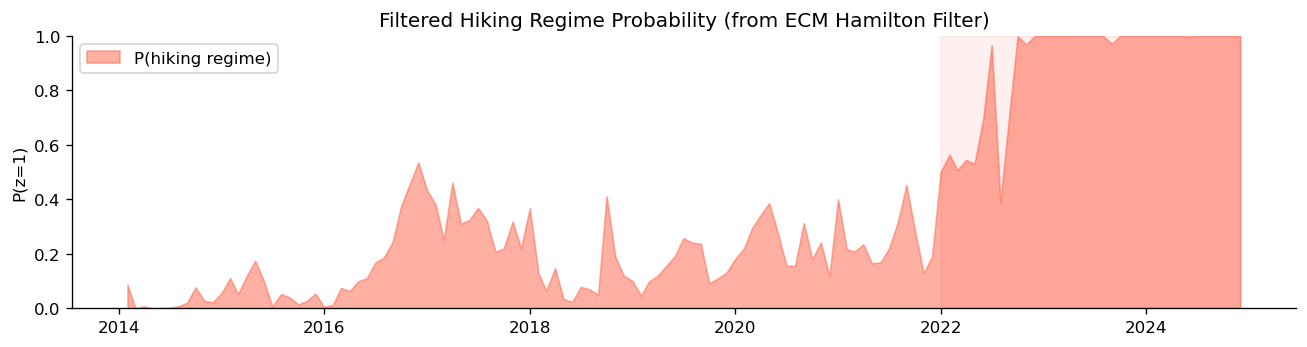

Mean P(hiking): pre-2022 = 0.174, post-2022 = 0.899


In [3]:
regime_probs = extract_regime_probs_numpy(idata_ecm, factors, deposits_arr)  # (T-1, 2)
p_hiking     = regime_probs[:, 1]  # P(z_t = 1 | y_{1:t})

fig, ax = plt.subplots(figsize=(11, 3))
ax.fill_between(dates[1:], p_hiking, alpha=0.5, color="tomato", label="P(hiking regime)")
ax.axvspan(pd.Timestamp("2022-01-01"), dates[-1], alpha=0.06, color="red")
ax.set_ylim(0, 1)
ax.set_ylabel("P(z=1)")
ax.set_title("Filtered Hiking Regime Probability (from ECM Hamilton Filter)")
ax.legend()
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
plt.tight_layout()
plt.show()

print(f"Mean P(hiking): pre-2022 = {p_hiking[dates[1:] < '2022'].mean():.3f}, "
      f"post-2022 = {p_hiking[dates[1:] >= '2022'].mean():.3f}")

## 3. Simulate Volumes

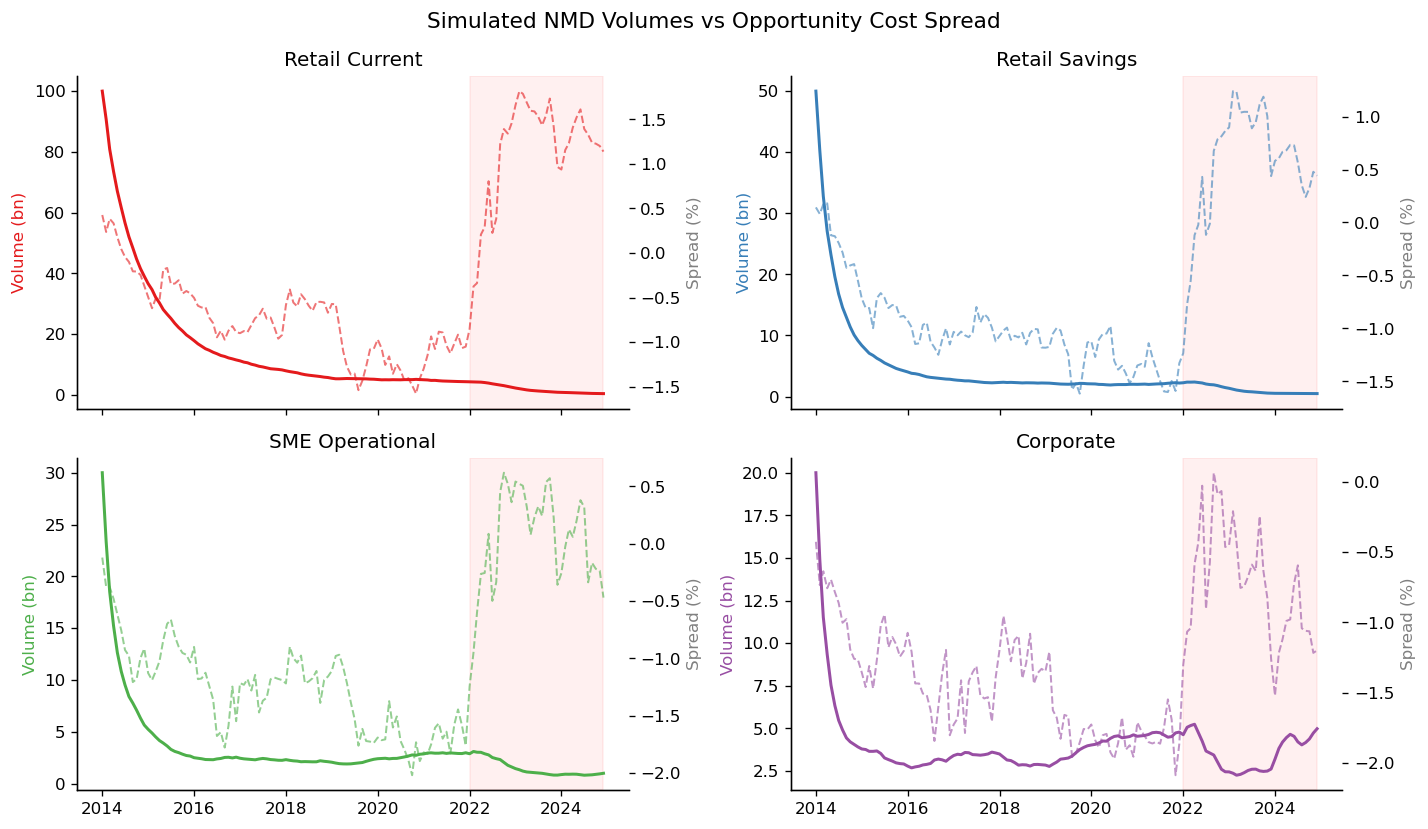

Volume change pre→post 2022 (regime switch):
  Retail Current        : 16.9 → 1.9  (-88.7%)
  Retail Savings        : 5.3 → 1.1  (-78.5%)
  SME Operational       : 3.9 → 1.5  (-61.1%)
  Corporate             : 4.1 → 3.6  (-13.8%)


In [4]:
rng     = np.random.default_rng(42)
volumes = simulate_volumes(deposits_arr, yields, regime_seq, rng)  # (T, S)
volumes_df = pd.DataFrame(volumes, index=dates, columns=SEGMENTS)

# Spread (opportunity cost)
from volume import compute_spread
spread = compute_spread(deposits_arr, yields)  # (T, S)
spread_df = pd.DataFrame(spread, index=dates, columns=SEGMENTS)

fig, axes = plt.subplots(2, 2, figsize=(12, 7), sharex=True)
for s, (ax, seg, c) in enumerate(zip(axes.flat, SEGMENTS, SEG_COLORS)):
    ax2 = ax.twinx()
    ax.plot(dates, volumes_df[seg], color=c, lw=1.8, label="Volume (left)")
    ax2.plot(dates, spread_df[seg], color=c, lw=1.2, ls="--", alpha=0.6, label="Spread (right)")
    ax.axvspan(pd.Timestamp("2022-01-01"), dates[-1], alpha=0.06, color="red")
    ax.set_title(seg)
    ax.set_ylabel("Volume (bn)", color=c)
    ax2.set_ylabel("Spread (%)", color="grey")
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

fig.suptitle("Simulated NMD Volumes vs Opportunity Cost Spread", fontsize=13)
fig.tight_layout()
plt.show()

print("Volume change pre→post 2022 (regime switch):")
idx_switch = (dates >= "2022-01-01")
for seg in SEGMENTS:
    pre  = volumes_df.loc[~idx_switch, seg].mean()
    post = volumes_df.loc[idx_switch,  seg].mean()
    print(f"  {seg:<22}: {pre:.1f} → {post:.1f}  ({(post/pre-1)*100:+.1f}%)")

## 4. Prior Predictive Check

Sampling: [alpha_z, beta0_z, dbeta_z, log_volumes, mu_alpha, mu_log_beta0, mu_log_dbeta, mu_logit_rho, rho_z, sigma_alpha, sigma_log_beta0, sigma_log_dbeta, sigma_logit_rho, sigma_v]


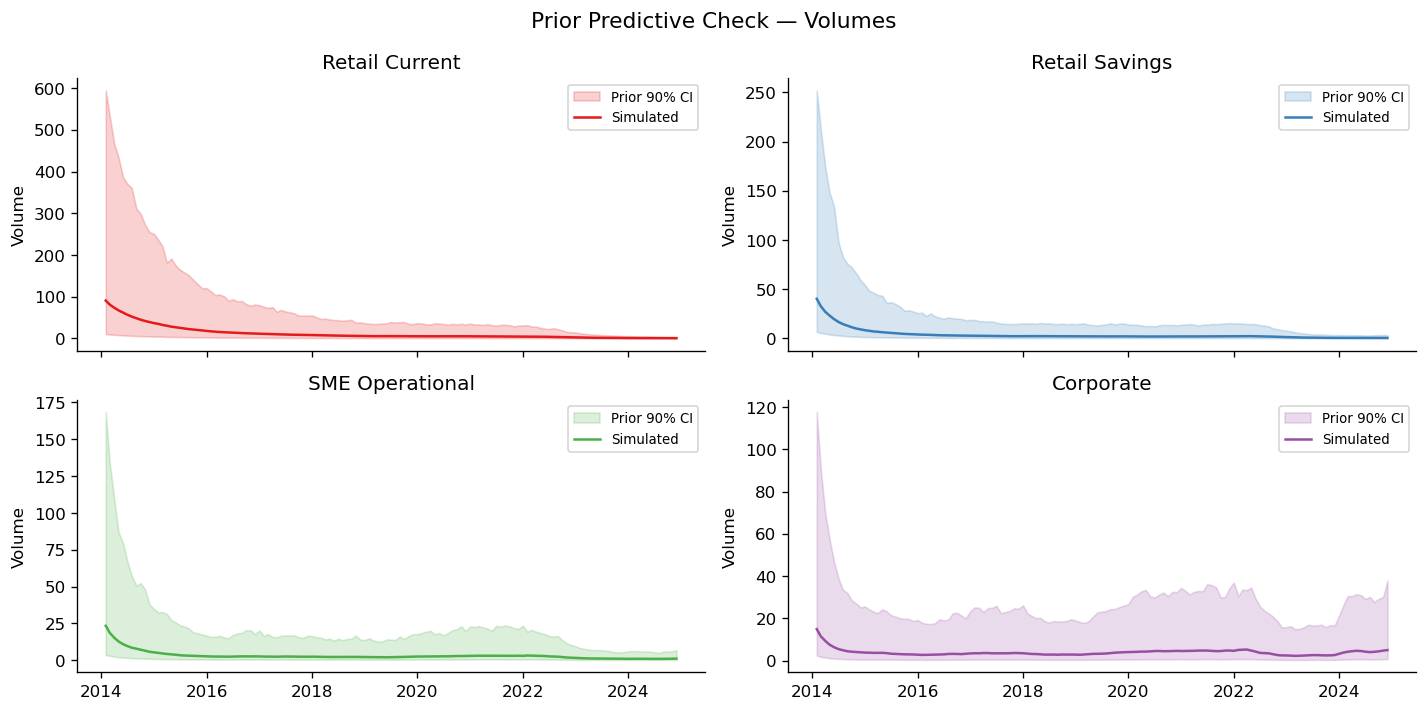

In [5]:
model = build_volume_model(volumes, deposits_arr, yields, regime_probs)

with model:
    prior_idata = pm.sample_prior_predictive(samples=200, random_seed=0)

ppc_prior = prior_idata.prior_predictive["log_volumes"].values  # (1, 200, T-1, S)
ppc_prior = np.exp(ppc_prior.reshape(-1, T - 1, len(SEGMENTS)))  # back to level

fig, axes = plt.subplots(2, 2, figsize=(12, 6), sharex=True)
for s, (ax, seg, c) in enumerate(zip(axes.flat, SEGMENTS, SEG_COLORS)):
    lo = np.percentile(ppc_prior[:, :, s], 5, axis=0)
    hi = np.percentile(ppc_prior[:, :, s], 95, axis=0)
    ax.fill_between(dates[1:], lo, hi, color=c, alpha=0.2, label="Prior 90% CI")
    ax.plot(dates[1:], volumes[1:, s], color=c, lw=1.5, label="Simulated")
    ax.set_title(seg)
    ax.set_ylabel("Volume")
    ax.legend(fontsize=8)
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
fig.suptitle("Prior Predictive Check — Volumes", fontsize=13)
fig.tight_layout()
plt.show()

## 5. NUTS Sampling

Pure hierarchical linear regression (no scan) — sampling is very fast.

In [6]:
with model:
    idata_vol = pm.sample(
        draws=2000,
        tune=3000,
        chains=4,
        target_accept=0.99,
        random_seed=42,
        progressbar=True,
        nuts_sampler="numpyro",
    )

print(az.summary(
    idata_vol,
    var_names=["mu_logit_rho", "mu_log_beta0", "mu_log_dbeta",
               "sigma_logit_rho", "sigma_log_beta0", "sigma_log_dbeta"],
))

C:\Users\thoma\.conda\envs\pymc_env\Lib\site-packages\threadpoolctl.py:1226: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)


  0%|          | 0/5000 [00:00<?, ?it/s]

  0%|          | 0/5000 [00:00<?, ?it/s]

  0%|          | 0/5000 [00:00<?, ?it/s]

  0%|          | 0/5000 [00:00<?, ?it/s]

There were 11 divergences after tuning. Increase `target_accept` or reparameterize.


                  mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  \
mu_logit_rho     2.969  0.337   2.360    3.631      0.006    0.005    3141.0   
mu_log_beta0    -3.381  0.271  -3.893   -2.881      0.004    0.004    3724.0   
mu_log_dbeta    -3.045  0.287  -3.583   -2.500      0.005    0.004    3897.0   
sigma_logit_rho  0.678  0.185   0.378    1.026      0.003    0.003    5042.0   
sigma_log_beta0  0.548  0.165   0.278    0.850      0.002    0.002    6529.0   
sigma_log_dbeta  0.574  0.169   0.298    0.896      0.002    0.002    7046.0   

                 ess_tail  r_hat  
mu_logit_rho       4310.0    1.0  
mu_log_beta0       4382.0    1.0  
mu_log_dbeta       5496.0    1.0  
sigma_logit_rho    5534.0    1.0  
sigma_log_beta0    5724.0    1.0  
sigma_log_dbeta    6022.0    1.0  


## 6. Parameter Recovery

In [7]:
post = idata_vol.posterior

def post_mean(name):
    return post[name].mean(("chain", "draw")).values

rho_est    = post_mean("rho")        # (S,)
beta0_est  = post_mean("beta0")      # (S,)
dbeta_est  = post_mean("delta_beta") # (S,)
beta1_est  = beta0_est + dbeta_est   # regime 1 sensitivity

print("Parameter recovery (posterior mean vs true):")
print(f"{'Segment':<22} {'ρ true':>8} {'ρ est':>8} {'β⁰ true':>9} {'β⁰ est':>9} {'β¹ true':>9} {'β¹ est':>9}")
print("-" * 80)
for s, seg in enumerate(SEGMENTS):
    print(f"{seg:<22} {TRUE_RHO[s]:>8.3f} {rho_est[s]:>8.3f}"
          f" {TRUE_BETA_V_R0[s]:>9.4f} {beta0_est[s]:>9.4f}"
          f" {TRUE_BETA_V_R1[s]:>9.4f} {beta1_est[s]:>9.4f}")

Parameter recovery (posterior mean vs true):
Segment                  ρ true    ρ est   β⁰ true    β⁰ est   β¹ true    β¹ est
--------------------------------------------------------------------------------
Retail Current            0.980    0.981   -0.0200   -0.0189   -0.0500   -0.0461
Retail Savings            0.950    0.951   -0.0300   -0.0281   -0.0800   -0.0693
SME Operational           0.920    0.928   -0.0500   -0.0406   -0.1200   -0.0848
Corporate                 0.880    0.895   -0.1000   -0.0613   -0.2000   -0.1608


## 7. Spread Sensitivity by Regime

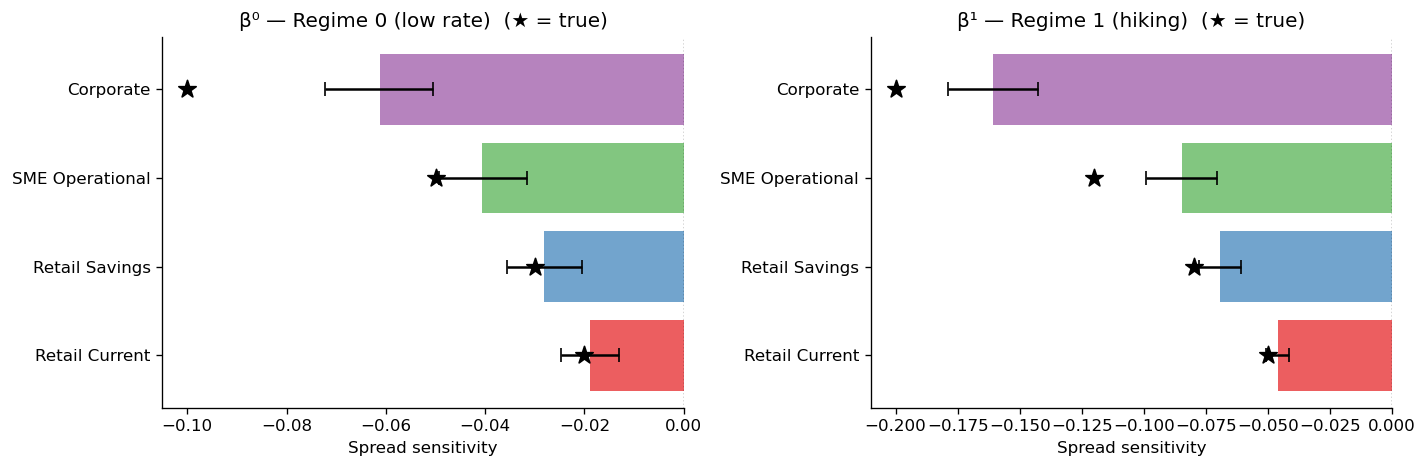


Regime amplification  |Δβ| / |β⁰|:
  Retail Current        : true = 1.50x  est = 1.43x
  Retail Savings        : true = 1.67x  est = 1.47x
  SME Operational       : true = 1.40x  est = 1.09x
  Corporate             : true = 1.00x  est = 1.62x


In [8]:
beta0_samples = post["beta0"].values.reshape(-1, len(SEGMENTS))  # (N, S)
beta1_samples = beta0_samples + post["delta_beta"].values.reshape(-1, len(SEGMENTS))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
x = np.arange(len(SEGMENTS))

for ax, samples, title, true_vals in [
    (axes[0], beta0_samples, "β⁰ — Regime 0 (low rate)", TRUE_BETA_V_R0),
    (axes[1], beta1_samples, "β¹ — Regime 1 (hiking)",   TRUE_BETA_V_R1),
]:
    means = samples.mean(axis=0)
    lo    = np.percentile(samples, 3,  axis=0)
    hi    = np.percentile(samples, 97, axis=0)
    ax.barh(x, means, color=SEG_COLORS, alpha=0.7, xerr=[means-lo, hi-means],
            error_kw={"ecolor": "black", "linewidth": 1.5}, capsize=4)
    for s, tv in enumerate(true_vals):
        ax.scatter(tv, s, color="black", marker="*", s=120, zorder=5)
    ax.set_yticks(x)
    ax.set_yticklabels(SEGMENTS)
    ax.axvline(0, color="black", lw=0.8, ls=":")
    ax.set_title(title + "  (★ = true)")
    ax.set_xlabel("Spread sensitivity")

fig.tight_layout()
plt.show()

print("\nRegime amplification  |Δβ| / |β⁰|:")
for s, seg in enumerate(SEGMENTS):
    amp_true = abs(TRUE_DELTA_BETA_V[s]) / abs(TRUE_BETA_V_R0[s])
    amp_est  = abs(dbeta_est[s]) / abs(beta0_est[s])
    print(f"  {seg:<22}: true = {amp_true:.2f}x  est = {amp_est:.2f}x")

## 8. Posterior Predictive Check

Sampling: [log_volumes]


Output()

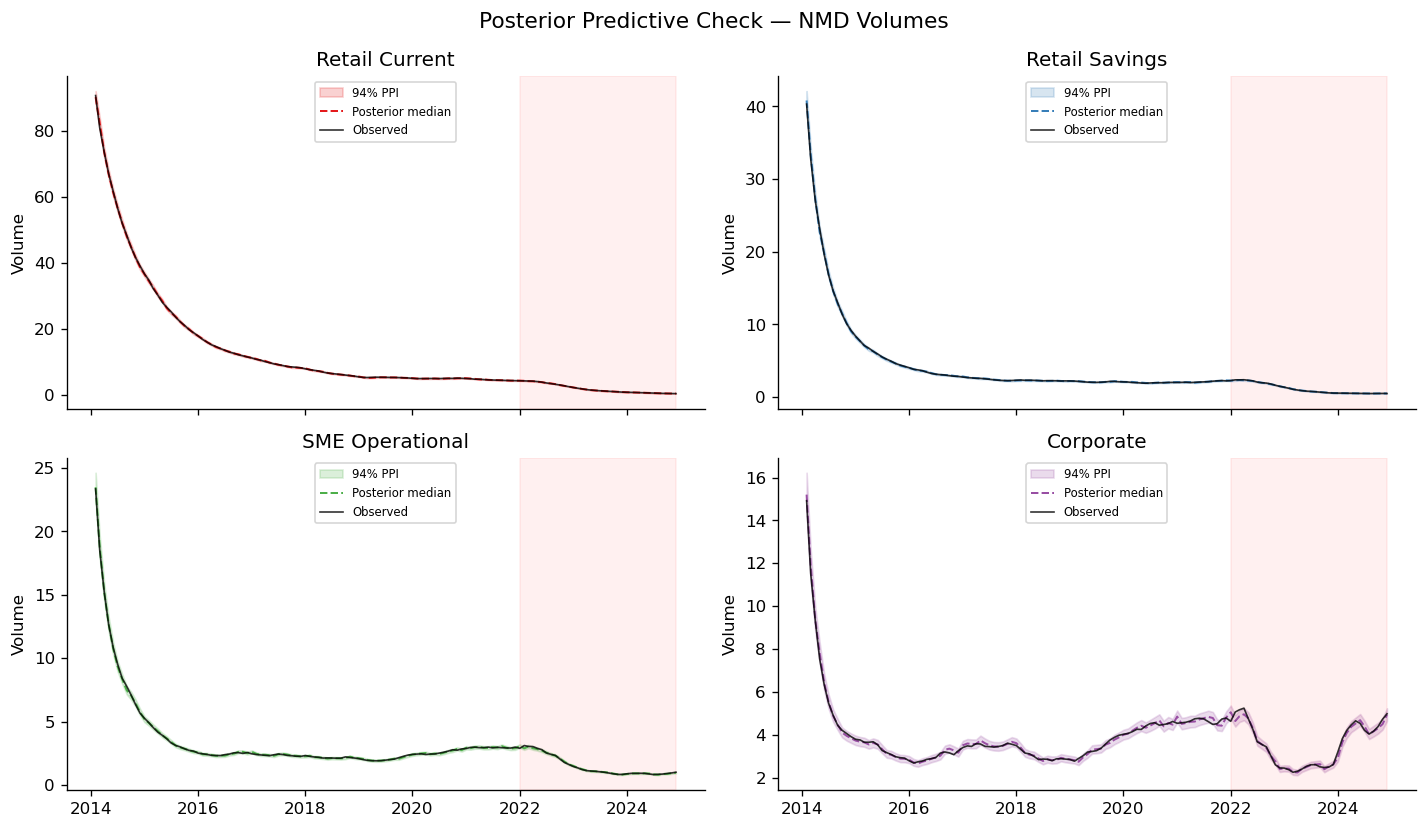

In [9]:
with model:
    ppc = pm.sample_posterior_predictive(idata_vol, random_seed=0)

ppc_samples = np.exp(
    ppc.posterior_predictive["log_volumes"].values.reshape(-1, T - 1, len(SEGMENTS))
)

fig, axes = plt.subplots(2, 2, figsize=(12, 7), sharex=True)
for s, (ax, seg, c) in enumerate(zip(axes.flat, SEGMENTS, SEG_COLORS)):
    lo  = np.percentile(ppc_samples[:, :, s], 3,  axis=0)
    hi  = np.percentile(ppc_samples[:, :, s], 97, axis=0)
    med = np.median(ppc_samples[:, :, s], axis=0)
    ax.fill_between(dates[1:], lo, hi, color=c, alpha=0.2, label="94% PPI")
    ax.plot(dates[1:], med, color=c, lw=1.2, ls="--", label="Posterior median")
    ax.plot(dates[1:], volumes[1:, s], color="black", lw=1.0, alpha=0.8, label="Observed")
    ax.axvspan(pd.Timestamp("2022-01-01"), dates[-1], alpha=0.06, color="red")
    ax.set_title(seg)
    ax.set_ylabel("Volume")
    ax.legend(fontsize=7)
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
fig.suptitle("Posterior Predictive Check — NMD Volumes", fontsize=13)
fig.tight_layout()
plt.show()

## 9. Historical NII

Monthly NII = V × spread / 12, where spread = 5y yield − deposit rate.

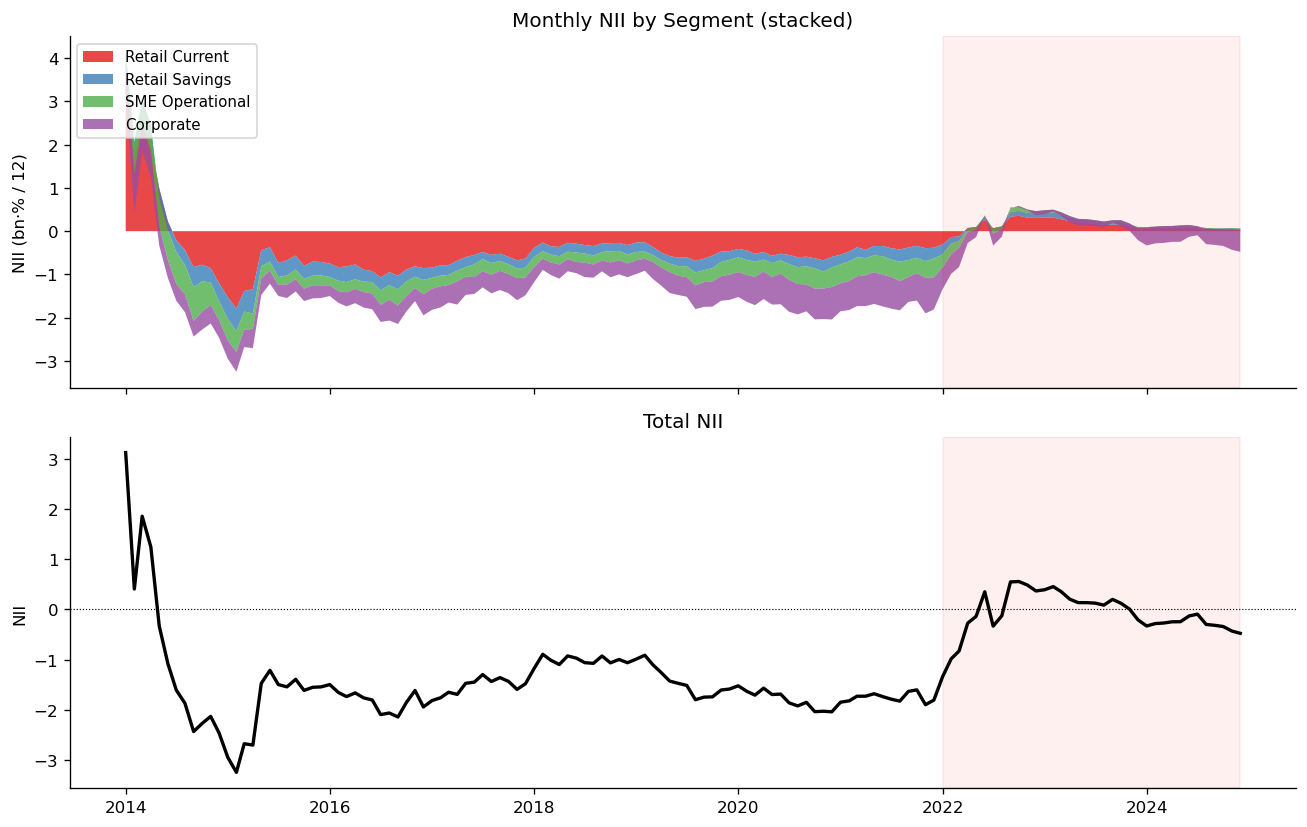

Mean monthly NII pre/post 2022 regime switch:
  Retail Current        : -0.454 → 0.125  (-127.4%)
  Retail Savings        : -0.231 → 0.031  (-113.5%)
  SME Operational       : -0.334 → -0.010  (-97.1%)
  Corporate             : -0.476 → -0.234  (-50.8%)
  Total                 : -1.495 → -0.088  (-94.1%)


In [10]:
nii = compute_nii(volumes_df, deposits_df, yields)  # (T, S)
nii_df = pd.DataFrame(nii, index=dates, columns=SEGMENTS)
nii_total = nii_df.sum(axis=1)

fig, axes = plt.subplots(2, 1, figsize=(11, 7), sharex=True)

ax = axes[0]
ax.stackplot(dates, [nii_df[seg] for seg in SEGMENTS],
             labels=SEGMENTS, colors=SEG_COLORS, alpha=0.8)
ax.axvspan(pd.Timestamp("2022-01-01"), dates[-1], alpha=0.06, color="red")
ax.set_title("Monthly NII by Segment (stacked)")
ax.set_ylabel("NII (bn·% / 12)")
ax.legend(loc="upper left", fontsize=9)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

ax = axes[1]
ax.plot(dates, nii_total, color="black", lw=2, label="Total NII")
ax.axvspan(pd.Timestamp("2022-01-01"), dates[-1], alpha=0.06, color="red")
ax.axhline(0, color="black", lw=0.7, ls=":")
ax.set_title("Total NII")
ax.set_ylabel("NII")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

fig.tight_layout()
plt.show()

print("Mean monthly NII pre/post 2022 regime switch:")
for seg in SEGMENTS + ["Total"]:
    s = nii_total if seg == "Total" else nii_df[seg]
    pre  = s[dates <  "2022-01-01"].mean()
    post = s[dates >= "2022-01-01"].mean()
    print(f"  {seg:<22}: {pre:.3f} → {post:.3f}  ({(post/pre-1)*100:+.1f}%)")

## 10. Scenario Analysis — Volumes and NII

Using the rate scenarios from notebook 05, we now propagate through volumes
to get the full NII picture under each scenario.

In [11]:
with open("../data/pipeline_results.pkl", "rb") as f:
    pipe = pickle.load(f)

H              = 12
forecast_dates = pd.date_range(dates[-1] + pd.DateOffset(months=1), periods=H, freq="MS")
SCENARIO_COLORS = ["#333333", "#d62728", "#1f77b4", "#8c564b", "#bcbd22"]

scenario_names    = pipe["scenario_names"]
scenario_factors  = pipe["scenario_factors"]   # dict name → (H, 3)
scenario_regimes  = pipe["scenario_regimes"]   # dict name → (H,) int
scenario_deposits = pipe["scenario_deposits"]  # dict name → (N, H, S)

print("Scenarios loaded:", scenario_names)

Scenarios loaded: ['Baseline', 'Parallel +200', 'Parallel -100', 'Steepener +100', 'Flattener -100']


In [12]:
# For each scenario: sample volumes using posterior predictive
scenario_volumes = {}
scenario_nii     = {}

for name in scenario_names:
    factors_new = scenario_factors[name]   # (H, 3)
    regime_new  = scenario_regimes[name]   # (H,) regime at each horizon

    # Extend regime_probs to horizon using assumed future regime
    p_new = regime_new.astype(float)       # P(z=1) = 0 or 1 (hard assignment)

    # Build yield DataFrame for scenario
    from diebold_li import LAMBDA_MAT
    y_new = factors_new @ LAMBDA_MAT.T     # (H, J)
    yields_new = pd.DataFrame(y_new, columns=yields.columns)

    # Posterior mean deposits for NII (use median across samples)
    dep_med = np.median(scenario_deposits[name], axis=0)   # (H, S)
    dep_new = pd.DataFrame(dep_med, columns=SEGMENTS)

    # Volume prediction
    vol_pred = predict_volumes(
        idata_vol, volumes, dep_new.values, yields_new, p_new
    )  # (N, H, S)
    scenario_volumes[name] = vol_pred

    # NII: compute per sample then summarise
    spread_new = yields_new["60m"].values[:, None] - dep_new.values   # (H, S)
    nii_pred   = vol_pred * spread_new[None, :, :] / 12               # (N, H, S)
    scenario_nii[name] = nii_pred

print("Volume and NII predictions computed for all scenarios.")

Volume and NII predictions computed for all scenarios.


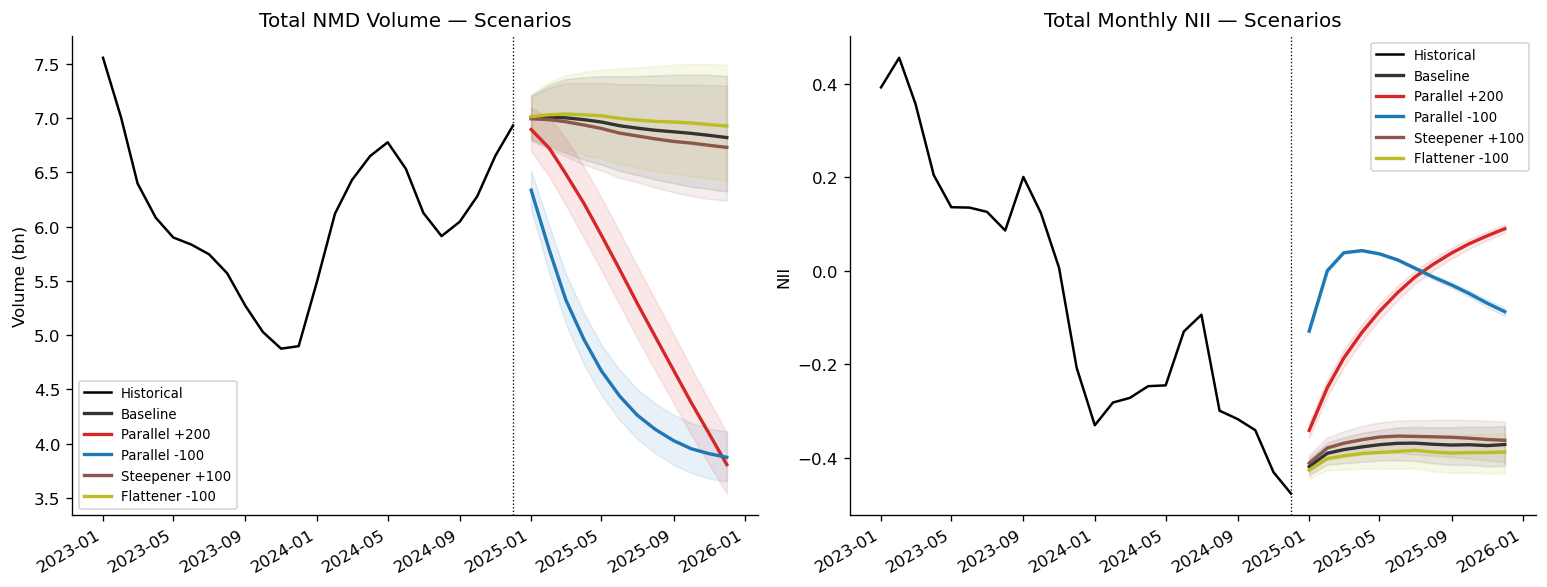

In [13]:
# Plot: total volumes under each scenario
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Historical tail + scenario volumes
ax = axes[0]
hist_vol_total = volumes_df.sum(axis=1).iloc[-24:]
ax.plot(hist_vol_total.index, hist_vol_total.values, color="black", lw=1.5, label="Historical")
for name, sc in zip(scenario_names, SCENARIO_COLORS):
    vol_total = np.median(scenario_volumes[name].sum(axis=2), axis=0)   # (H,)
    lo = np.percentile(scenario_volumes[name].sum(axis=2), 10, axis=0)
    hi = np.percentile(scenario_volumes[name].sum(axis=2), 90, axis=0)
    ax.fill_between(forecast_dates, lo, hi, color=sc, alpha=0.1)
    ax.plot(forecast_dates, vol_total, color=sc, lw=2, label=name)
ax.axvline(dates[-1], color="black", lw=0.8, ls=":")
ax.set_title("Total NMD Volume — Scenarios")
ax.set_ylabel("Volume (bn)")
ax.legend(fontsize=8)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))

# Total NII under each scenario
ax = axes[1]
hist_nii_total = nii_df.sum(axis=1).iloc[-24:]
ax.plot(hist_nii_total.index, hist_nii_total.values, color="black", lw=1.5, label="Historical")
for name, sc in zip(scenario_names, SCENARIO_COLORS):
    nii_total = np.median(scenario_nii[name].sum(axis=2), axis=0)  # (H,)
    lo = np.percentile(scenario_nii[name].sum(axis=2), 10, axis=0)
    hi = np.percentile(scenario_nii[name].sum(axis=2), 90, axis=0)
    ax.fill_between(forecast_dates, lo, hi, color=sc, alpha=0.1)
    ax.plot(forecast_dates, nii_total, color=sc, lw=2, label=name)
ax.axvline(dates[-1], color="black", lw=0.8, ls=":")
ax.set_title("Total Monthly NII — Scenarios")
ax.set_ylabel("NII")
ax.legend(fontsize=8)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))

fig.autofmt_xdate(rotation=30)
fig.tight_layout()
plt.show()

## 11. NII Summary Table

Posterior median NII at 12-month horizon, by scenario.

In [14]:
print("NII at 12-month horizon — posterior median (80% PI)")
print("=" * 70)
print(f"{'Scenario':<22} {'Total NII':>15} {'vs Baseline':>12}")
print("-" * 50)

baseline_nii = np.median(scenario_nii["Baseline"].sum(axis=2)[:, -1])
for name in scenario_names:
    nii_H = scenario_nii[name].sum(axis=2)[:, -1]  # (N,) total NII at H=12
    med   = np.median(nii_H)
    lo    = np.percentile(nii_H, 10)
    hi    = np.percentile(nii_H, 90)
    diff  = med - baseline_nii
    print(f"{name:<22} {med:>6.3f} [{lo:.3f},{hi:.3f}]  {diff:>+10.3f}")

print("\nVolume at 12-month horizon — posterior median")
print("=" * 70)
print(f"{'Scenario':<22}" + "".join(f" {s[:10]:>12}" for s in SEGMENTS))
print("-" * (22 + 12 * len(SEGMENTS)))
for name in scenario_names:
    vols_H = np.median(scenario_volumes[name][:, -1, :], axis=0)  # (S,)
    print(f"{name:<22}" + "".join(f" {v:>12.1f}" for v in vols_H))

NII at 12-month horizon — posterior median (80% PI)
Scenario                     Total NII  vs Baseline
--------------------------------------------------
Baseline               -0.372 [-0.417,-0.332]      +0.000
Parallel +200           0.090 [0.081,0.099]      +0.462
Parallel -100          -0.087 [-0.097,-0.079]      +0.284
Steepener +100         -0.363 [-0.409,-0.322]      +0.009
Flattener -100         -0.388 [-0.433,-0.348]      -0.016

Volume at 12-month horizon — posterior median
Scenario                 Retail Cur   Retail Sav   SME Operat    Corporate
----------------------------------------------------------------------
Baseline                        0.3          0.5          1.1          5.0
Parallel +200                   0.2          0.2          0.6          2.8
Parallel -100                   0.4          0.6          1.0          1.9
Steepener +100                  0.3          0.4          1.0          5.0
Flattener -100                  0.3          0.5          1.2   

In [15]:
import pickle, os
os.makedirs("../data", exist_ok=True)
with open("../data/volume_results.pkl", "wb") as f:
    pickle.dump({"idata": idata_vol, "volumes_hist": volumes_df}, f)
print("Saved to ../data/volume_results.pkl")

Saved to ../data/volume_results.pkl
